In [323]:
print("Customer Churn Prediction")
print("Total Customers:", len(df))
print("Churned Customers:", df['Churn'].sum())
print("Model Accuracy:", accuracy)

Customer Churn Prediction
Total Customers: 7032
Churned Customers: 1869
Model Accuracy: 0.7960199004975125


In [324]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [325]:
import pandas as pd

In [326]:
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [327]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [328]:
df.shape

(7043, 21)

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [330]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [331]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [332]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [333]:
df.duplicated().sum()

np.int64(0)

In [334]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [335]:
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [336]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [337]:
df = df.dropna()

In [338]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [339]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [340]:
df['gender'].value_counts()

,count
gender,
Male,3549
Female,3483


In [341]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [342]:
df['MonthlyCharges'].mean()

np.float64(64.79820819112628)

In [343]:
df['MonthlyCharges'].max()

118.75

In [344]:
df['MonthlyCharges'].min()

18.25

In [345]:
df['tenure'].mean()

np.float64(32.421786120591584)

In [346]:
pd.crosstab(df['gender'],df['Churn'])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [347]:
pd.crosstab(df['Contract'],df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [348]:
pd.crosstab(df['InternetService'],df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [349]:
import matplotlib.pyplot as plt

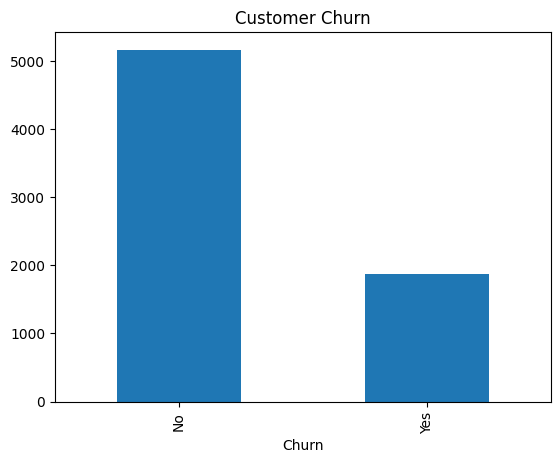

In [350]:
df['Churn'].value_counts().plot(kind = 'bar')
plt.title('Customer Churn')
plt.show()

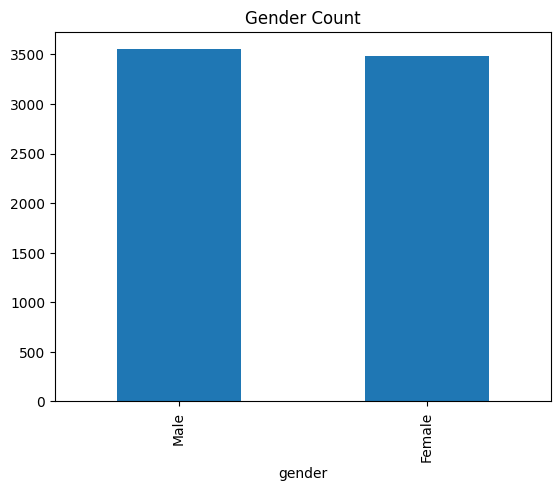

In [351]:
df['gender'].value_counts().plot(kind = 'bar')
plt.title('Gender Count')
plt.show()

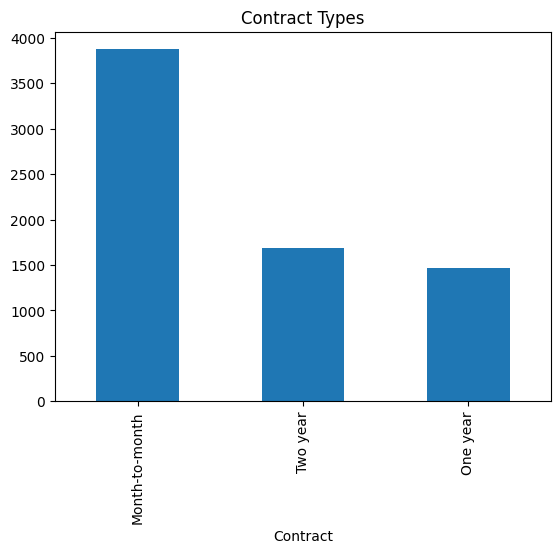

In [352]:
df['Contract'].value_counts().plot(kind = 'bar')
plt.title('Contract Types')
plt.show()

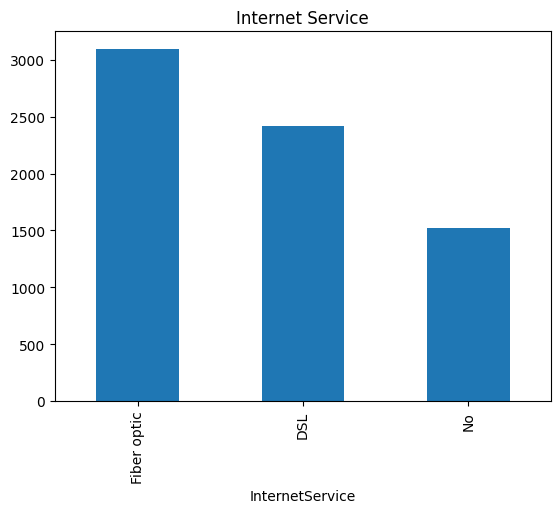

In [353]:
df['InternetService'].value_counts().plot(kind = 'bar')
plt.title('Internet Service')
plt.show()

In [354]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [355]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [356]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [357]:
df.nunique()

,0
customerID,7032
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [358]:
df['TotalCharges'].dtype

dtype('float64')

In [359]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [360]:
from sklearn.preprocessing import LabelEncoder

In [361]:
le = LabelEncoder()

In [362]:
df.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [363]:
df['gender'] = le.fit_transform(df['gender'])

In [364]:
df['gender'].head()

,gender
0,0
1,1
2,1
3,1
4,0


In [365]:
df['Partner'] = le.fit_transform(df['Partner'])

In [366]:
df['Dependents'] = le.fit_transform(df['Dependents'])

In [367]:
df['PhoneService'] = le.fit_transform(df['PhoneService'])

In [368]:
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

In [369]:
df['MultipleLines'] = le.fit_transform(df['MultipleLines'])

In [370]:
df['InternetService'] = le.fit_transform(df['InternetService'])

In [371]:
df['OnlineSecurity'] = le.fit_transform(df['OnlineSecurity'])

In [372]:
df['OnlineBackup'] = le.fit_transform(df['OnlineBackup'])

In [373]:
df['DeviceProtection'] = le.fit_transform(df['DeviceProtection'])

In [374]:
df['TechSupport'] = le.fit_transform(df['TechSupport'])

In [375]:
df['StreamingTV'] = le.fit_transform(df['StreamingTV'])

In [376]:
df['StreamingMovies'] = le.fit_transform(df['StreamingMovies'])

In [377]:
df['Contract'] = le.fit_transform(df['Contract'])

In [378]:
df['PaymentMethod'] = le.fit_transform(df['PaymentMethod'])

In [379]:
df['Churn'] = le.fit_transform(df['Churn'])

In [380]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [381]:
df = df.drop('customerID', axis=1)

In [382]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [383]:
X = df.drop('Churn' , axis=1)

In [384]:
y = df['Churn']

In [385]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [386]:
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [387]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [388]:
print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [389]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)

In [390]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [391]:
y_pred = model.predict(X_test)

In [392]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7924662402274343


In [393]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [394]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [395]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [396]:
y_pred = model.predict(X_test)

In [397]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8024164889836531


In [398]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[910 105]
 [173 219]]


In [399]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1015
           1       0.68      0.56      0.61       392

    accuracy                           0.80      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



In [400]:
from sklearn.metrics import roc_auc_score

probability = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, probability))

ROC-AUC: 0.8483487483663417


In [401]:
df.corr()['Churn'].sort_values()

,Churn
Contract,-0.396150
tenure,-0.354049
OnlineSecurity,-0.289050
TechSupport,-0.282232
TotalCharges,-0.199484
OnlineBackup,-0.195290
DeviceProtection,-0.177883
Dependents,-0.163128
Partner,-0.149982
InternetService,-0.047097


In [402]:
df.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.192858
PaperlessBilling,0.191454
SeniorCitizen,0.150541
PaymentMethod,0.107852
MultipleLines,0.038043
PhoneService,0.011691
gender,-0.008545
StreamingTV,-0.036303
StreamingMovies,-0.038802


In [403]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,0,1
Contract,,
0,2220,1655
1,1306,166
2,1637,48


In [404]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,0,1
InternetService,,
0,1957,459
1,1799,1297
2,1407,113


In [405]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,0,1
PaymentMethod,,
0,1284,258
1,1289,232
2,1294,1071
3,1296,308


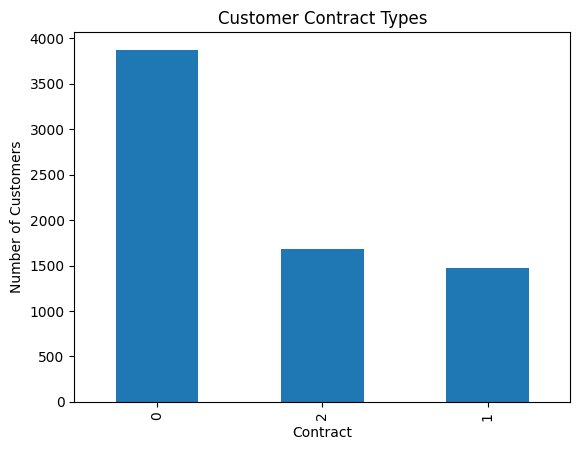

In [406]:
df['Contract'].value_counts().plot(kind='bar')

plt.title('Customer Contract Types')
plt.xlabel('Contract')
plt.ylabel('Number of Customers')

plt.show()

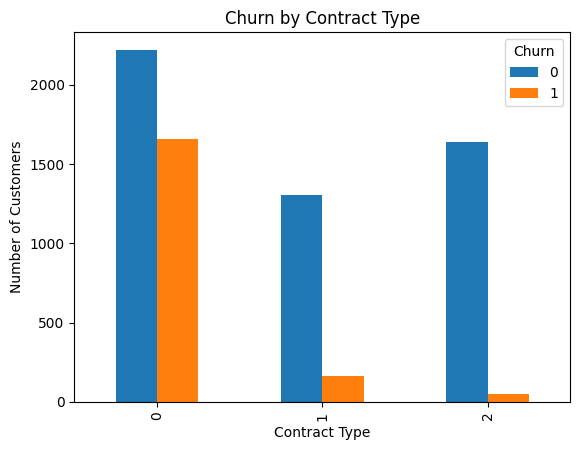

In [407]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

In [408]:
df.to_csv('cleaned_customer_churn.csv', index=False)

In [409]:
df.shape

(7032, 20)

In [410]:
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


In [411]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [412]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498
